# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

 # **Dataset Loading**

In [ ]:
# Load California Housing dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# Quick check
print(df.shape)
print(df.isnull().sum().sum())
print(df.head())

(20640, 9)
0
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


# **Split Dataset**(80/20)


In [ ]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

Train: 16512 samples
Test: 4128 samples


# **Train Linear Regression Model**

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained")
print(f"Intercept: {model.intercept_:.4f}")

Model trained
Intercept: -37.0233


In [ ]:
y_pred = model.predict(X_test)

# **Metrics Calculation**

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

RMSE: 0.7456
MAE: 0.5332
R²: 0.5758


# **Plot** (Actual vs Predicted)

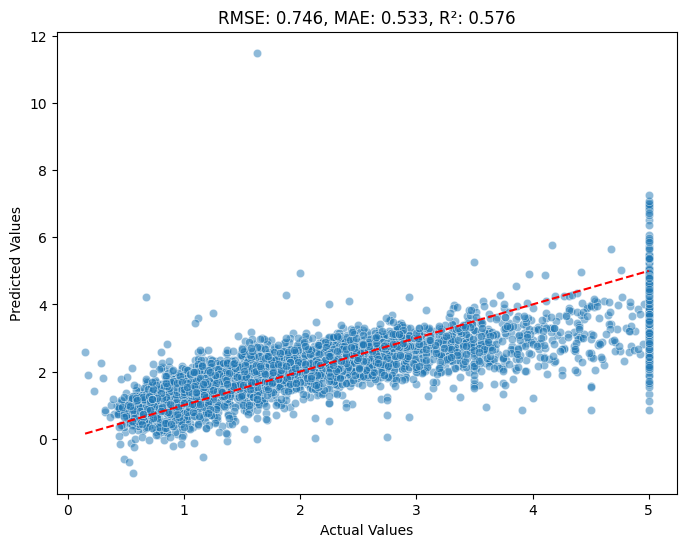

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='white', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'RMSE: {rmse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}')
plt.savefig('predicted_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

# Residual Plot

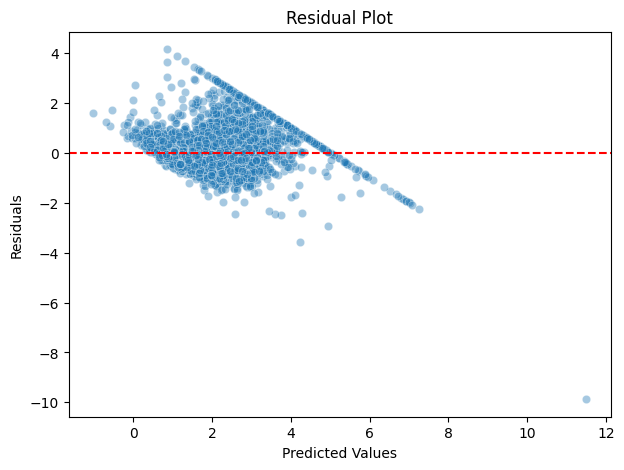

In [12]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.4, edgecolors='white', linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=1.5)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.savefig('residual_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Distribution of Residuals

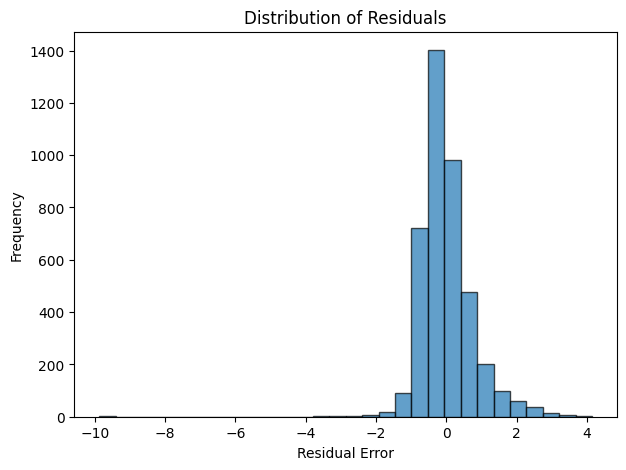

Residuals - Mean: 0.003479 (should be near 0)
Residuals - Std:  0.7457


In [13]:
plt.figure(figsize=(7, 5))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Residual Error')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.savefig('residual_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Residuals - Mean: {residuals.mean():.6f} (should be near 0)")
print(f"Residuals - Std:  {residuals.std():.4f}")

In [ ]:
print(f"The model explains {r2*100:.1f}% of the variance in house prices.")
print(f"Typical prediction error is ${mae*100000:.0f}.")
print(f"The plot shows points reasonably scattered around the diagonal line, indicating a decent fit.")

The model explains 57.6% of the variance in house prices.
Typical prediction error is $53320.
The plot shows points reasonably scattered around the diagonal line, indicating a decent fit.
